In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_KEY"] = "271e18429a1a55a0496a3ef5a0dfc2fe"
# Note: This is an example. You should replace the value with your actual Kaggle API key.

In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets list -s numtadb

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
pip install kaggle

In [ ]:
!kaggle auth login

usage: kaggle [-h] [-v] [-W]
              {competitions,c,datasets,d,kernels,k,models,m,files,f,benchmarks,b,config,auth}
              ...
kaggle: error: argument command: unknown parser 'auth' (choices: competitions, c, datasets, d, kernels, k, models, m, files, f, benchmarks, b, config)


In [ ]:
!export KAGGLE_API_TOKEN=KGAT_271e18429a1a55a0496a3ef5a0dfc2fe

In [ ]:
!kaggle datasets list -s numtadb

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!mkdir -p /content/numtadb

!kaggle datasets download \
    -d BengaliAI/numta \
    -p /content/numtadb

Dataset URL: https://www.kaggle.com/datasets/BengaliAI/numta
License(s): CC-BY-SA-4.0
100% 1.91G/1.91G [01:12<00:00, 28.1MB/s]



In [ ]:
!ls -lh /content/numtadb

total 2.0G
-rw-r--r-- 1 root root 2.0G Sep 30  2019 numta.zip


In [ ]:
import zipfile
import os

zip_files = [
    f for f in os.listdir("/content/numtadb")
    if f.endswith(".zip")
]

print(zip_files)

zip_path = os.path.join(
    "/content/numtadb",
    zip_files[0]
)

extract_path = "/content/numtadb/extracted"

os.makedirs(
    extract_path,
    exist_ok=True
)

with zipfile.ZipFile(
    zip_path,
    "r"
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )

print("Extraction completed.")

['numta.zip']
Extraction completed.


In [ ]:
!find /content/numtadb/extracted -maxdepth 2 -type d | head -30

/content/numtadb/extracted
/content/numtadb/extracted/training-d
/content/numtadb/extracted/testing-f
/content/numtadb/extracted/training-b
/content/numtadb/extracted/testing-a
/content/numtadb/extracted/training-a
/content/numtadb/extracted/testing-all-corrected
/content/numtadb/extracted/testing-all-corrected/testing-f
/content/numtadb/extracted/testing-all-corrected/testing-a
/content/numtadb/extracted/testing-all-corrected/testing-e
/content/numtadb/extracted/testing-all-corrected/testing-c
/content/numtadb/extracted/testing-all-corrected/testing-d
/content/numtadb/extracted/testing-all-corrected/testing-augc
/content/numtadb/extracted/testing-all-corrected/testing-auga
/content/numtadb/extracted/testing-all-corrected/testing-b
/content/numtadb/extracted/training-e
/content/numtadb/extracted/testing-e
/content/numtadb/extracted/testing-c
/content/numtadb/extracted/training-c
/content/numtadb/extracted/testing-d
/content/numtadb/extracted/testing-augc
/content/numtadb/extracted/test

In [ ]:
import os
import pandas as pd

# Only datasets that actually exist
AVAILABLE_SOURCES = [
    "a",
    "b",
    "c",
    "d",
    "e"
]

# Assuming `extract_path` is defined from a previous cell
# and contains the extracted dataset in folders like 'training-a', 'training-b', etc.
# and CSVs like 'training-a.csv', 'training-b.csv', etc.
csv_files = {
    source: os.path.join(extract_path, f"training-{source}.csv")
    for source in AVAILABLE_SOURCES
}

training_dirs = {
    source: os.path.join(extract_path, f"training-{source}")
    for source in AVAILABLE_SOURCES
}

all_dataframes = []

for source in AVAILABLE_SOURCES:

    csv_path = csv_files[source]
    folder_path = training_dirs[source]

    # Safety check
    if not os.path.exists(csv_path):
        print(
            f"Skipping training-{source}: CSV not found"
        )
        continue

    if not os.path.exists(folder_path):
        print(
            f"Skipping training-{source}: Folder not found"
        )
        continue

    # Read CSV
    df = pd.read_csv(csv_path)

    # Add source information
    df["source"] = source

    # Create full image path
    df["image_path"] = df["filename"].apply(
        lambda x: os.path.join(
            folder_path,
            str(x)
        )
    )

    all_dataframes.append(df)

    print(
        f"training-{source}: "
        f"{len(df):,} CSV records loaded"
    )

# Combine
combined_df = pd.concat(
    all_dataframes,
    ignore_index=True
)

print("\n" + "="*50)

print(
    "Total combined CSV records:",
    f"{len(combined_df):,}"
)

print("="*50)


training-a: 19,702 CSV records loaded
training-b: 359 CSV records loaded
training-c: 24,298 CSV records loaded
training-d: 10,908 CSV records loaded
training-e: 16,778 CSV records loaded

Total combined CSV records: 72,045


In [ ]:
from tqdm.auto import tqdm

tqdm.pandas()

combined_df["exists"] = combined_df[
    "image_path"
].progress_apply(
    os.path.exists
)

total_records = len(combined_df)

existing_images = combined_df[
    "exists"
].sum()

missing_images = (
    ~combined_df["exists"]
).sum()

print(
    "Total CSV records:",
    f"{total_records:,}"
)

print(
    "Physical images found:",
    f"{existing_images:,}"
)

print(
    "Missing images:",
    f"{missing_images:,}"
)

  0%|          | 0/72045 [00:00<?, ?it/s]

Total CSV records: 72,045
Physical images found: 72,045
Missing images: 0


In [ ]:
print("Total records:", len(combined_df))
print("Images found:", combined_df["exists"].sum())
print("Missing images:", (~combined_df["exists"]).sum())

print("\nClasses:")
print(sorted(combined_df["digit"].unique()))

print("\nDataset sources:")
print(combined_df["source"].value_counts().sort_index())

Total records: 72045
Images found: 72045
Missing images: 0

Classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Dataset sources:
source
a    19702
b      359
c    24298
d    10908
e    16778
Name: count, dtype: int64


In [ ]:
import hashlib
from tqdm.auto import tqdm

def md5_hash(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


tqdm.pandas()

combined_df["image_hash"] = combined_df[
    "image_path"
].progress_apply(
    md5_hash
)

duplicate_count = combined_df[
    "image_hash"
].duplicated().sum()

print(
    "Total images:",
    len(combined_df)
)

print(
    "Exact duplicate images:",
    duplicate_count
)

  0%|          | 0/72045 [00:00<?, ?it/s]

Total images: 72045
Exact duplicate images: 18


In [ ]:
# Remove exact duplicate images
before_count = len(combined_df)

combined_df = combined_df.drop_duplicates(
    subset=["image_hash"],
    keep="first"
).reset_index(drop=True)

after_count = len(combined_df)

print("Images before duplicate removal:", before_count)
print("Duplicate images removed:", before_count - after_count)
print("Images after duplicate removal:", after_count)

Images before duplicate removal: 72045
Duplicate images removed: 18
Images after duplicate removal: 72027


In [ ]:
import matplotlib.pyplot as plt

class_distribution = (
    combined_df["digit"]
    .value_counts()
    .sort_index()
)

print(class_distribution)

print(
    "\nTotal images:",
    class_distribution.sum()
)

digit
0    7238
1    7192
2    7223
3    7231
4    7251
5    7238
6    7210
7    7175
8    7157
9    7112
Name: count, dtype: int64

Total images: 72027


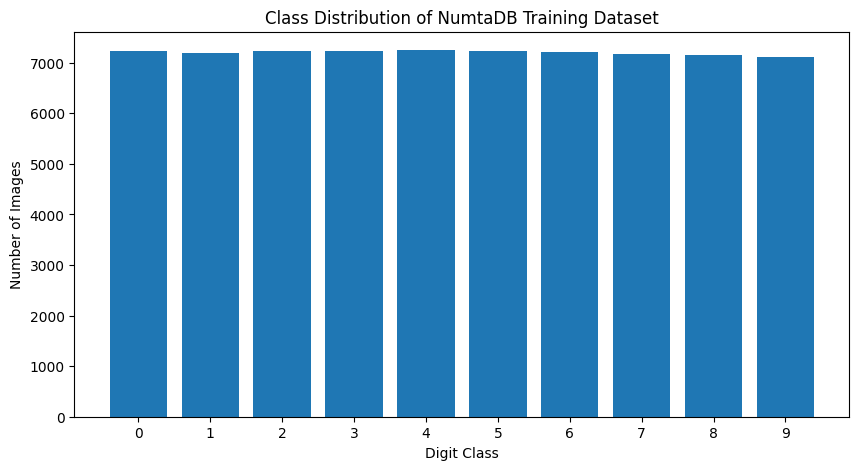

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution.index,
    class_distribution.values
)

plt.xlabel("Digit Class")
plt.ylabel("Number of Images")

plt.title(
    "Class Distribution of NumtaDB Training Dataset"
)

plt.xticks(range(10))

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# First split:
# 70% training
# 30% temporary (validation + test)

train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.30,
    stratify=combined_df["digit"],
    random_state=42
)

# Second split:
# Split the 30% temporary data equally
# 15% validation
# 15% test

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["digit"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training images: 50418
Validation images: 10804
Test images: 10805
Total: 72027


In [ ]:
print("\nTraining distribution:")
print(
    train_df["digit"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["digit"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nTest distribution:")
print(
    test_df["digit"]
    .value_counts(normalize=True)
    .sort_index()
)


Training distribution:
digit
0    0.100480
1    0.099845
2    0.100282
3    0.100401
4    0.100678
5    0.100500
6    0.100103
7    0.099607
8    0.099369
9    0.098735
Name: proportion, dtype: float64

Validation distribution:
digit
0    0.100518
1    0.099870
2    0.100241
3    0.100333
4    0.100611
5    0.100426
6    0.100148
7    0.099685
8    0.099408
9    0.098760
Name: proportion, dtype: float64

Test distribution:
digit
0    0.100509
1    0.099861
2    0.100324
3    0.100416
4    0.100694
5    0.100509
6    0.100046
7    0.099584
8    0.099306
9    0.098751
Name: proportion, dtype: float64


In [ ]:
OUTPUT_DIR = "/content/numtadb_processed"

import os
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

train_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test.csv"
    ),
    index=False
)

print("Train/validation/test CSV files saved successfully.")

Train/validation/test CSV files saved successfully.


In [ ]:
print("Train/validation/test CSV files saved successfully.")

Train/validation/test CSV files saved successfully.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 32
BATCH_SIZE = 64
NUM_CLASSES = 10

print("TensorFlow:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

TensorFlow: 2.20.0
Eager execution: True


In [ ]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nExample:")
print(train_df[["filename", "image_path", "digit"]].head())

Training: 50418
Validation: 10804
Test: 10805

Training columns:
['filename', 'original filename', 'scanid', 'digit', 'database name original', 'contributing team', 'database name', 'source', 'image_path', 'num', 'districtid', 'institutionid', 'gender', 'age', 'datestamp', 'exists', 'image_hash']

Example:
         filename                                        image_path  digit
6474   a06474.png  /content/numtadb/extracted/training-a/a06474.png      6
65647  e10391.png  /content/numtadb/extracted/training-e/e10391.png      7
57550  e02287.png  /content/numtadb/extracted/training-e/e02287.png      8
66729  e11474.png  /content/numtadb/extracted/training-e/e11474.png      2
58888  e03625.png  /content/numtadb/extracted/training-e/e03625.png      2


In [ ]:
def preprocess_image(path, label):

    # Read image file
    image = tf.io.read_file(path)

    # Decode as grayscale
    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    # Resize to 32 x 32
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Convert to float32
    image = tf.cast(image, tf.float32)

    # Normalize ONCE
    image = image / 255.0

    # Explicit shape
    image.set_shape(
        [IMG_SIZE, IMG_SIZE, 1]
    )

    return image, label

In [ ]:
def create_dataset(df, shuffle=False):

    paths = df["image_path"].values
    labels = df["digit"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_dataset = create_dataset(
    train_df,
    shuffle=True
)

val_dataset = create_dataset(
    val_df,
    shuffle=False
)

test_dataset = create_dataset(
    test_df,
    shuffle=False
)

print("Datasets created successfully.")

Datasets created successfully.


In [ ]:
print(
    "Train batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        val_dataset
    ).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(
        test_dataset
    ).numpy()
)

Train batches: 788
Validation batches: 169
Test batches: 169


In [ ]:
images, labels = next(iter(train_dataset))

print("========== DATASET CHECK ==========")
print("Image shape :", images.shape)
print("Image dtype :", images.dtype)
print("Label shape :", labels.shape)

print(
    "Minimum     :",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum     :",
    tf.reduce_max(images).numpy()
)

print(
    "Mean        :",
    tf.reduce_mean(images).numpy()
)

========== DATASET CHECK ==========
Image shape : (64, 32, 32, 1)
Image dtype : <dtype: 'float32'>
Label shape : (64,)
Minimum     : 0.0
Maximum     : 1.0
Mean        : 0.802659


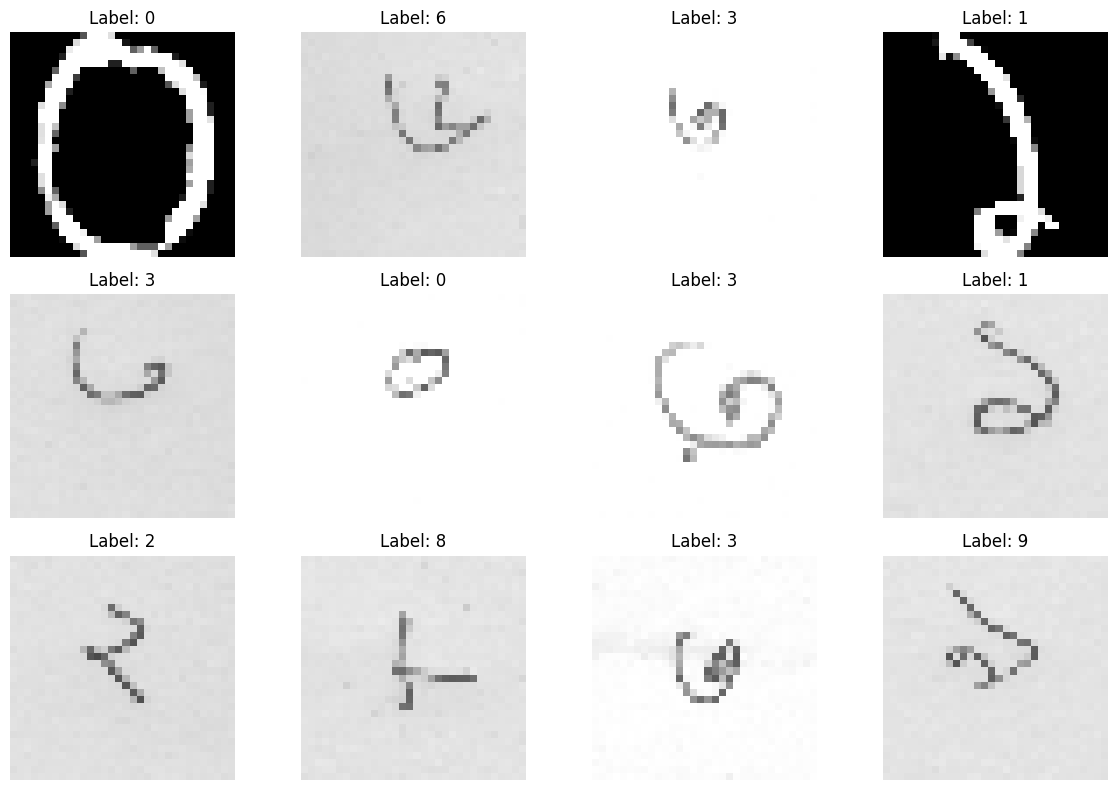

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(12):

    img = images[i].numpy().squeeze()

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        img,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Label: {labels[i].numpy()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([

    # Small rotation
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    # Small horizontal and vertical translation
    tf.keras.layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    ),

    # Small zoom
    tf.keras.layers.RandomZoom(
        height_factor=0.08,
        width_factor=0.08
    ),

], name="data_augmentation")

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [ ]:
def residual_ds_block(x, filters, stride=1):

    shortcut = x

    # Depthwise convolution
    x = tf.keras.layers.DepthwiseConv2D(
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Pointwise convolution
    x = tf.keras.layers.Conv2D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    # Adjust shortcut if dimensions change
    if stride != 1 or shortcut.shape[-1] != filters:

        shortcut = tf.keras.layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    # Residual connection
    x = tf.keras.layers.Add()([
        x,
        shortcut
    ])

    x = tf.keras.layers.ReLU()(x)

    return x

In [ ]:
inputs = tf.keras.Input(
    shape=(32, 32, 1),
    name="input"
)

# Data augmentation
x = data_augmentation(inputs)

# Initial feature extraction
x = tf.keras.layers.Conv2D(
    64,
    kernel_size=3,
    padding="same",
    use_bias=False
)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)

# Block 1
x = residual_ds_block(
    x,
    filters=64
)

x = tf.keras.layers.MaxPooling2D(
    pool_size=2
)(x)

# Block 2
x = residual_ds_block(
    x,
    filters=128
)

x = tf.keras.layers.MaxPooling2D(
    pool_size=2
)(x)

# Block 3
x = residual_ds_block(
    x,
    filters=192
)

# Block 4
x = residual_ds_block(
    x,
    filters=256
)

# Feature refinement
x = tf.keras.layers.Conv2D(
    256,
    kernel_size=1,
    padding="same",
    use_bias=False
)(x)

x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.ReLU()(x)

# Global Average Pooling
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Regularization
x = tf.keras.layers.Dropout(
    0.30
)(x)

# Output
outputs = tf.keras.layers.Dense(
    10,
    activation="softmax",
    name="output"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Proposed_Lightweight_CNN_V3"
)

model.summary()

Model: "Proposed_Lightweight_CNN_V3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 1) │          0 │ input[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 32,    │        576 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_7  │ (None, 32, 32,    │        576 │ re_lu_18[0][0]    │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 32,    │      4,096 │ re_lu_19[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 32, 32,    │          0 │ add_7[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ re_lu_20[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_8  │ (None, 16, 16,    │        576 │ max_pooling2d_4[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │      8,192 │ re_lu_21[0][0]    │
│                     │ 128)              │            │                 

 Total params: 248,586 (971.04 KB)

 Trainable params: 244,618 (955.54 KB)

 Non-trainable params: 3,968 (15.50 KB)

In [ ]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("V3 compiled successfully.")

V3 compiled successfully.


In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_proposed_cnn_v3.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.5894 - loss: 1.1794
Epoch 1: val_accuracy improved from None to 0.64513, saving model to best_proposed_cnn_v3.keras

Epoch 1: finished saving model to best_proposed_cnn_v3.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 330s 382ms/step - accuracy: 0.7936 - loss: 0.6219 - val_accuracy: 0.6451 - val_loss: 1.4797 - learning_rate: 0.0010
Epoch 2/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.9418 - loss: 0.1881
Epoch 2: val_accuracy improved from 0.64513 to 0.68169, saving model to best_proposed_cnn_v3.keras

Epoch 2: finished saving model to best_proposed_cnn_v3.keras
788/788 ━━━━━━━━━━━━━━━━━━━━ 318s 377ms/step - accuracy: 0.9453 - loss: 0.1749 - val_accuracy: 0.6817 - val_loss: 1.2930 - learning_rate: 0.0010
Epoch 3/50
788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9563 - loss: 0.1372
Epoch 3: val_accuracy did not improve from 0.68169
788/788 ━━━━━━━━━━━━━━━━━━━━ 328s 390ms/step - accuracy: 0.9572 - loss: 0.13

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.9850 - loss: 0.0525
Test Loss: 0.052524346858263016
Test Accuracy: 0.9850069284439087
Test Accuracy (%): 98.50069284439087


In [ ]:
best_val_accuracy = max(
    history.history["val_accuracy"]
)

print(
    "Best Validation Accuracy:",
    best_val_accuracy
)

print(
    "Best Validation Accuracy (%):",
    best_val_accuracy * 100
)

Best Validation Accuracy: 0.9838948249816895
Best Validation Accuracy (%): 98.38948249816895


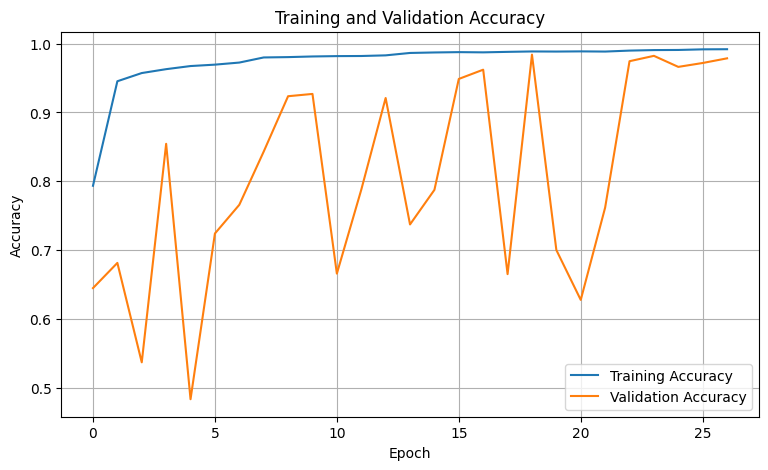

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()

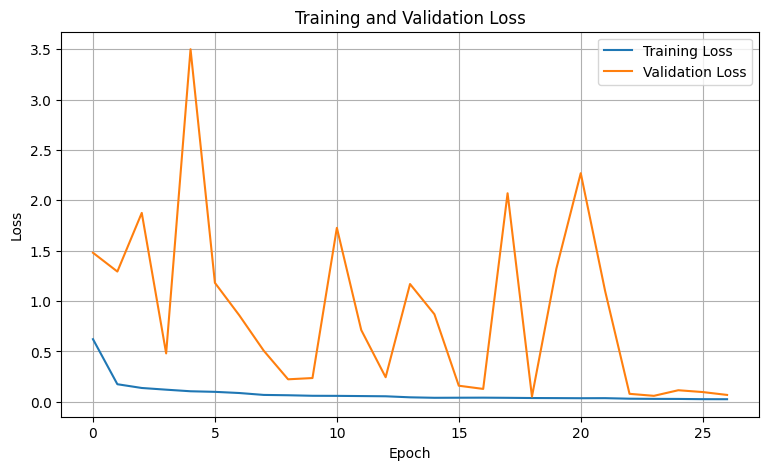

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

y_true = []
y_pred = []

for batch_images, batch_labels in test_dataset:

    predictions = model.predict(
        batch_images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        batch_labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9889    0.9880    0.9885      1086
           1     0.9695    0.9713    0.9704      1079
           2     0.9872    0.9982    0.9927      1084
           3     0.9643    0.9945    0.9791      1085
           4     0.9890    0.9917    0.9904      1088
           5     0.9898    0.9807    0.9852      1086
           6     0.9952    0.9621    0.9784      1081
           7     0.9972    0.9907    0.9939      1076
           8     0.9898    0.9991    0.9944      1073
           9     0.9802    0.9738    0.9770      1067

    accuracy                         0.9850     10805
   macro avg     0.9851    0.9850    0.9850     10805
weighted avg     0.9851    0.9850    0.9850     10805



In [ ]:
trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape)
    for v in model.non_trainable_weights
])

total_params = (
    trainable_params +
    non_trainable_params
)

print("==============================")
print("MODEL COMPLEXITY")
print("==============================")
print(
    f"Total Parameters     : {total_params:,}"
)
print(
    f"Trainable Parameters : {trainable_params:,}"
)
print(
    f"Non-trainable        : {non_trainable_params:,}"
)
print(
    f"Test Accuracy        : {test_accuracy * 100:.4f}%"
)
print("==============================")

MODEL COMPLEXITY
Total Parameters     : 248,586
Trainable Parameters : 244,618
Non-trainable        : 3,968
Test Accuracy        : 98.5007%


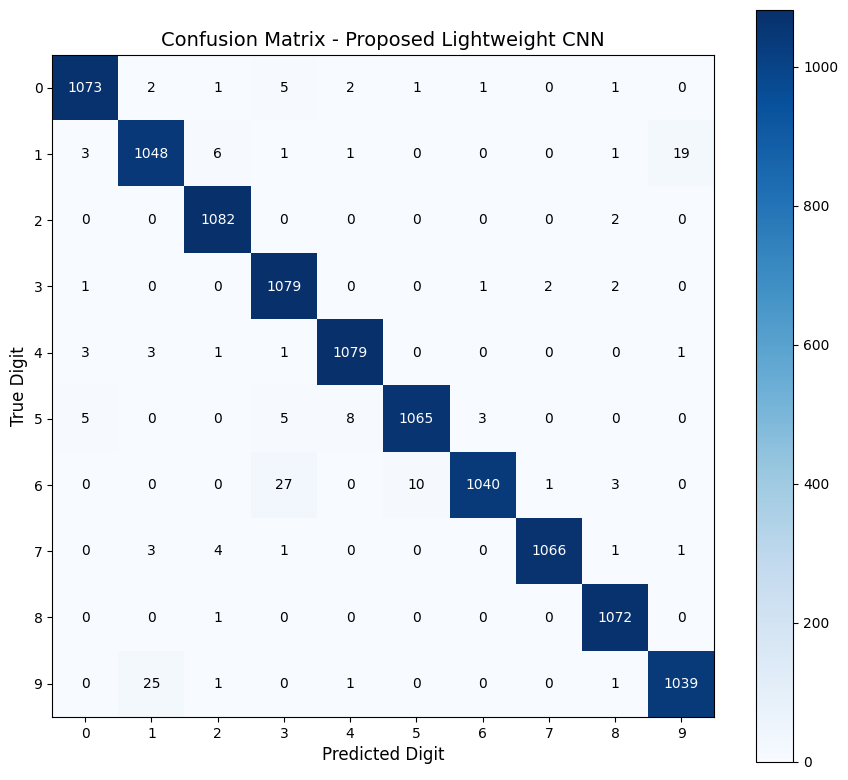

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for batch_images, batch_labels in test_dataset:

    predictions = model.predict(
        batch_images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(batch_labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot
plt.figure(figsize=(9, 8))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Proposed Lightweight CNN",
    fontsize=14
)

plt.colorbar()

plt.xlabel(
    "Predicted Digit",
    fontsize=12
)

plt.ylabel(
    "True Digit",
    fontsize=12
)

plt.xticks(
    np.arange(10),
    np.arange(10)
)

plt.yticks(
    np.arange(10),
    np.arange(10)
)

# Write values inside cells
threshold = cm.max() / 2

for i in range(10):
    for j in range(10):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=10
        )

plt.tight_layout()

# Save high-quality image
plt.savefig(
    "confusion_matrix_v3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()